### **SUPERDENSE CODING**

In [6]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
def alice_strategy(msg, qc):
    if msg == 1:
        return qc
    elif msg == 2:
        qc.z(0)
        return qc
    elif msg == 3:
        qc.x(0)
        return qc
    elif msg == 4:
        qc.x(0)
        qc.z(0)
        return qc
    else:
        print("Invalid option")

print("""To send a secret location as a msg to bob:
1. INDIA
2. JAPAN
3. USA
4. AUSTRALIA""")

alice_msg = int(input("Enter choice (1-4): "))

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()

prepared_ct = alice_strategy(alice_msg, qc)
prepared_ct.barrier()

prepared_ct.cx(0, 1)
prepared_ct.h(0)
prepared_ct.measure([0, 1], [0, 1])

simulator = AerSimulator()
result = simulator.run(prepared_ct, shots=1).result()
counts = result.get_counts()
outcome = list(counts.keys())[0] 

print(prepared_ct.draw('text'))

print(f"Measured Bitstring: |{outcome}\u27E9")

location_map = {"00": "INDIA", "01": "JAPAN", "10": "USA", "11": "AUSTRALIA"}
print(f"Bob successfully decoded the secret location as: {location_map[outcome]}")

To send a secret location as a msg to bob:
1. INDIA
2. JAPAN
3. USA
4. AUSTRALIA
     ┌───┐      ░ ┌───┐ ░      ┌───┐┌─┐
q_0: ┤ H ├──■───░─┤ X ├─░───■──┤ H ├┤M├
     └───┘┌─┴─┐ ░ └───┘ ░ ┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─░───────░─┤ X ├─┤M├──╫─
          └───┘ ░       ░ └───┘ └╥┘  ║ 
c: 2/════════════════════════════╩═══╩═
                                 1   0 
Measured Bitstring: |10⟩
Bob successfully decoded the secret location as: USA


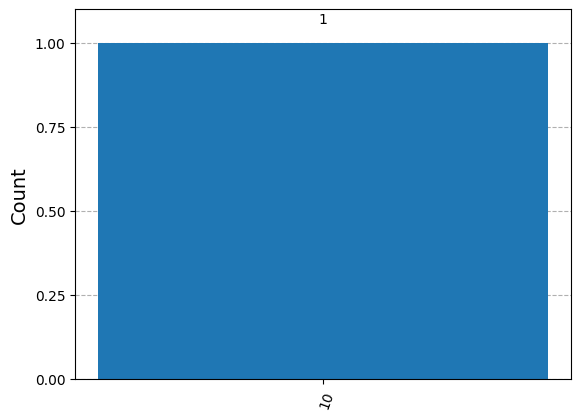

In [3]:
plot_histogram(counts)